# 01. Entrenament del model

Aquest notebook ajusta el model ELO-Poisson bivariant a partir del 
conjunt net de partits internacionals (2000–2026). El procés consta 
de tres etapes:

1. **Grid search:** optimització dels factors 
   multiplicatius del *learning rate* $k$ i del paràmetre $k_\Gamma$ 
   mitjançant validació creuada temporal.

2. **Algorisme EM:** estimació conjunta dels coeficients del GLM 
   $\boldsymbol{\theta} = (\alpha, \beta_1, \beta_2, \theta, \gamma)$ 
   i dels ràtings ELO ($OF$, $DF$, $\Gamma_C$) a través d'un bucle 
   iteratiu que alterna l'actualització dels ràtings i l'ajust del 
   GLM.

3. **Exportació del model entrenat:** els paràmetres i valors pels elos final `results/training/`.

4. **Visualitzacions:** Visualitzacions de la evolució dels ràtings en les confederacions i de la distribució de probabilitat de gols.

In [2]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import poisson

In [3]:
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)

from src.model import expected_goals
from src.converge import converge_model
from src.elo import simulate_elos
from src.grid_search import grid_search_optimized, csv_to_dict

Primer de tot, llegim les dades que hem processat, anteriorment.

In [4]:
df = pd.read_csv("../data/processed/df.csv")
df["date"] = pd.to_datetime(df["date"], format="%Y-%m-%d")

Carreguem el diccionari per obtenir de cada equip la seva confederació.

In [4]:
import json
from pathlib import Path

project_root = Path.cwd().parent
json_path_1 = project_root / 'data' / 'raw' / 'team-conf.json'
json_path_2 = project_root / 'data' / 'raw' / 'conf-team.json'


with open(json_path_1, 'r', encoding='utf-8') as f:
    team_conf_dict = json.load(f)

with open(json_path_2, 'r', encoding='utf-8') as f:
    conf_team_dict = json.load(f)

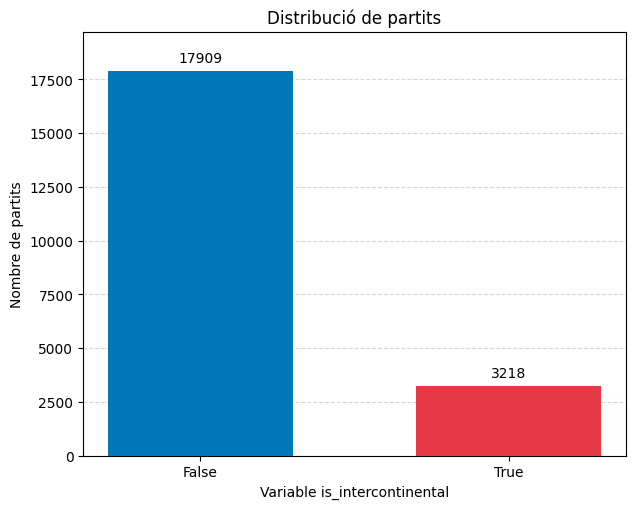

In [12]:
# 1. Calcular las frecuencias de los datos
conteo = df["is_intercontinental"].value_counts()

# Asegurar el orden de los datos si existen ambos valores (False primero, True después)
frecuencias = [conteo.get(False, 0), conteo.get(True, 0)]
categorias = ["False", "True"]
colores = ["#0077b6", "#e63946"] # Azul y Rojo coral

# 2. Configurar el lienzo de la gráfica
plt.figure(figsize=(7, 5.5))
plt.grid(axis='y', linestyle='--', alpha=0.5, zorder=0) # Líneas de fondo blandas

# 3. Crear el gráfico de barras
# zorder=3 hace que las barras queden por encima de las líneas de la cuadrícula
barras = plt.bar(categorias, frecuencias, color=colores, width=0.6, zorder=3)

# 4. Añadir las etiquetas numéricas encima de cada barra
for barra in barras:
    alto = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2.0, # Posición X (centro de la barra)
        alto + (max(frecuencias) * 0.015),       # Posición Y (ligeramente arriba del tope)
        f'{int(alto)}',                          # Texto a mostrar (el número entero)
        ha='center',                             # Alineación horizontal al centro
        va='bottom',                             # Alineación vertical
    )

# 5. Personalizar títulos y ejes
plt.title("Distribució de partits"
)
plt.xlabel("Variable is_intercontinental")
plt.ylabel("Nombre de partits")

# Limitar el eje Y un poco más arriba del máximo para que quepan bien los números
plt.ylim(0, max(frecuencias) * 1.1)

# Quitar bordes innecesarios (arriba y derecha) para un diseño más limpio
for spine in ["top", "right"]:
    plt.gca().spines[spine].set

Seguidament, configurem la cerca en graella, per estimar els paràmetres k:

In [6]:
"""
# En cas de ser primera execución, es pot generar el csv:
# Primer de tot, definim els folds:

df_train_fold1 = df[df["date"] < "2015-01-01"]
df_valid_fold1 = df[(df["date"] >= "2015-01-01") & (df["date"] < "2017-01-01")]

df_train_fold2 = df[df["date"] < "2017-01-01"]
df_valid_fold2 = df[(df["date"] >= "2017-01-01") & (df["date"] < "2019-01-01")]

df_train_fold3 = df[df["date"] < "2019-01-01"]
df_valid_fold3 = df[(df["date"] >= "2019-01-01") & (df["date"] < "2021-01-01")]

df_train_fold4 = df[df["date"] < "2021-01-01"]
df_valid_fold4 = df[(df["date"] >= "2021-01-01") & (df["date"] < "2023-01-01")]

df_folds = {
    "fold1": (df_train_fold1, df_valid_fold1),
    "fold2": (df_train_fold2, df_valid_fold2),
    "fold3": (df_train_fold3, df_valid_fold3),
    "fold4": (df_train_fold4, df_valid_fold4)
}

# Segudiament, definim els paràmetres a buscar:
dict_search = {
    'eta' : [0.01, 0.025, 0.05],
    'k_0' : [0.05],
    'intercontinental' : {
        'True' : [1.2, 1.5, 1.7, 2.0],
        'False' : [1.0]
    },
    'stage' : {
        'Qualification' : [1.2, 1.5, 1.7, 2.0],
        'Tournament' : [1.2, 1.5, 1.7, 2.0],
        'Other' : [1.0]
    },
    'competition' : {
        'World_Cup' : [2.5, 3.0, 3.5, 4.0],
        'Continental_Cup' : [1.5, 1.7, 2.0, 2.5],
        'Secundary_Continental_Cup' : [1.0, 1.2, 1.5],
        'International_Cup' : [1.0, 1.2, 1.5],
        'Friendlies' : [1.0]
    }
}

dict_k, loss = grid_search_optimized(df_folds, team_conf_dict, dict_search)
df_dict_k = pd.json_normalize(dict_k)
df_dict_k.to_csv("../results/training/grid_search.csv", index=False)
"""

'\n# En cas de ser primera execución, es pot generar el csv:\n# Primer de tot, definim els folds:\n\ndf_train_fold1 = df[df["date"] < "2015-01-01"]\ndf_valid_fold1 = df[(df["date"] >= "2015-01-01") & (df["date"] < "2017-01-01")]\n\ndf_train_fold2 = df[df["date"] < "2017-01-01"]\ndf_valid_fold2 = df[(df["date"] >= "2017-01-01") & (df["date"] < "2019-01-01")]\n\ndf_train_fold3 = df[df["date"] < "2019-01-01"]\ndf_valid_fold3 = df[(df["date"] >= "2019-01-01") & (df["date"] < "2021-01-01")]\n\ndf_train_fold4 = df[df["date"] < "2021-01-01"]\ndf_valid_fold4 = df[(df["date"] >= "2021-01-01") & (df["date"] < "2023-01-01")]\n\ndf_folds = {\n    "fold1": (df_train_fold1, df_valid_fold1),\n    "fold2": (df_train_fold2, df_valid_fold2),\n    "fold3": (df_train_fold3, df_valid_fold3),\n    "fold4": (df_train_fold4, df_valid_fold4)\n}\n\n# Segudiament, definim els paràmetres a buscar:\ndict_search = {\n    \'eta\' : [0.01, 0.025, 0.05],\n    \'k_0\' : [0.05],\n    \'intercontinental\' : {\n        \'

In [7]:
# En cas de ser execució posterior, es pot carregar el csv:
dict_k = csv_to_dict("../results/training/grid_search_train.csv")
params = pd.read_csv("../results/training/model_params.csv").iloc[0].to_dict()

In [8]:
# df_matches, df_ranking, df_confs, params, __, __ = converge_model(df, team_conf_dict, dict_k, max_iterations=30)
df_matches, df_ranking, df_confs =  simulate_elos(df, team_conf_dict, dict_k, params = params)

Plotear elos

In [9]:
home_df = df_matches[['date', 'home', 
            'Home_Offensive_ELO', 'Home_Defensive_ELO']].rename(
    columns={
        'home': 'team',
        'Home_Offensive_ELO': 'off_elo',
        'Home_Defensive_ELO': 'def_elo',
    }
)

# Bloc per als equips visitants
away_df = df_matches[['date', 'away',
            'Away_Offensive_ELO', 'Away_Defensive_ELO']].rename(
    columns={
        'away': 'team',
        'Away_Offensive_ELO': 'off_elo',
        'Away_Defensive_ELO': 'def_elo',
    }
)

evolution = pd.concat([home_df, away_df], ignore_index=True)
evolution['date'] = pd.to_datetime(evolution['date'])
evolution = evolution.sort_values(['team', 'date']).reset_index(drop=True)

In [10]:
def plot_elos_evolution(evolution, conf, conf_team_dict, highlight_teams = None):

    colours = ["#0077b6", "#e63946", "#2a9d8f", "#f4a261", "#8338ec"]

    if len(highlight_teams) > len(colours):
        return

    conf_teams = conf_team_dict[conf]
    evolution_conf = evolution[evolution['team'].isin(conf_teams)].copy()

    highlight_data = []

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

    # === Panel esquerre: ràting ofensiu ===
    for team in conf_teams:
        if team in highlight_teams:
            continue  

        team_data = evolution_conf[evolution_conf['team'] == team].sort_values('date')
        if len(team_data) > 1:
            axes[0].plot(team_data['date'], team_data['off_elo'],
                        color='#cccccc', alpha=0.4, linewidth=0.7, zorder=1)

    for team in highlight_teams:
        highlight_data.append(evolution_conf[evolution_conf['team'] == team].sort_values('date'))

    for i in range(len(highlight_teams)):
        axes[0].plot(highlight_data[i]['date'], highlight_data[i]['off_elo'],
                    color=colours[i], linewidth=1.0, label=highlight_teams[i], zorder=10)


    axes[0].axhline(0, color='black', linestyle='--', alpha=0.4, linewidth=0.8)
    axes[0].set_title("Ràting ofensiu", fontsize=13)
    axes[0].set_xlabel("Any")
    axes[0].set_ylabel("OF ELO")
    axes[0].legend(loc='upper left', frameon=True)

    # === Panel dret: ràting defensiu ===
    # Resta d'equips
    for team in conf_teams:
        if team in highlight_teams:
            continue
        team_data = evolution_conf[evolution_conf['team'] == team].sort_values('date')
        if len(team_data) > 1:
            axes[1].plot(team_data['date'], team_data['def_elo'],
                        color='#cccccc', alpha=0.4, linewidth=0.7, zorder=1)

    for i in range(len(highlight_teams)):
        axes[1].plot(highlight_data[i]['date'], highlight_data[i]['def_elo'],
                    color=colours[i], linewidth=1.0, label=highlight_teams[i], zorder=10)


    axes[1].axhline(0, color='black', linestyle='--', alpha=0.4, linewidth=0.8)
    axes[1].set_title("Ràting defensiu", fontsize=13)
    axes[1].set_xlabel("Any")
    axes[1].set_ylabel("DF ELO")
    axes[1].legend(loc='upper left', frameon=True)

    fig.suptitle(f"Evolució dels ELOs — {conf}", 
                fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()

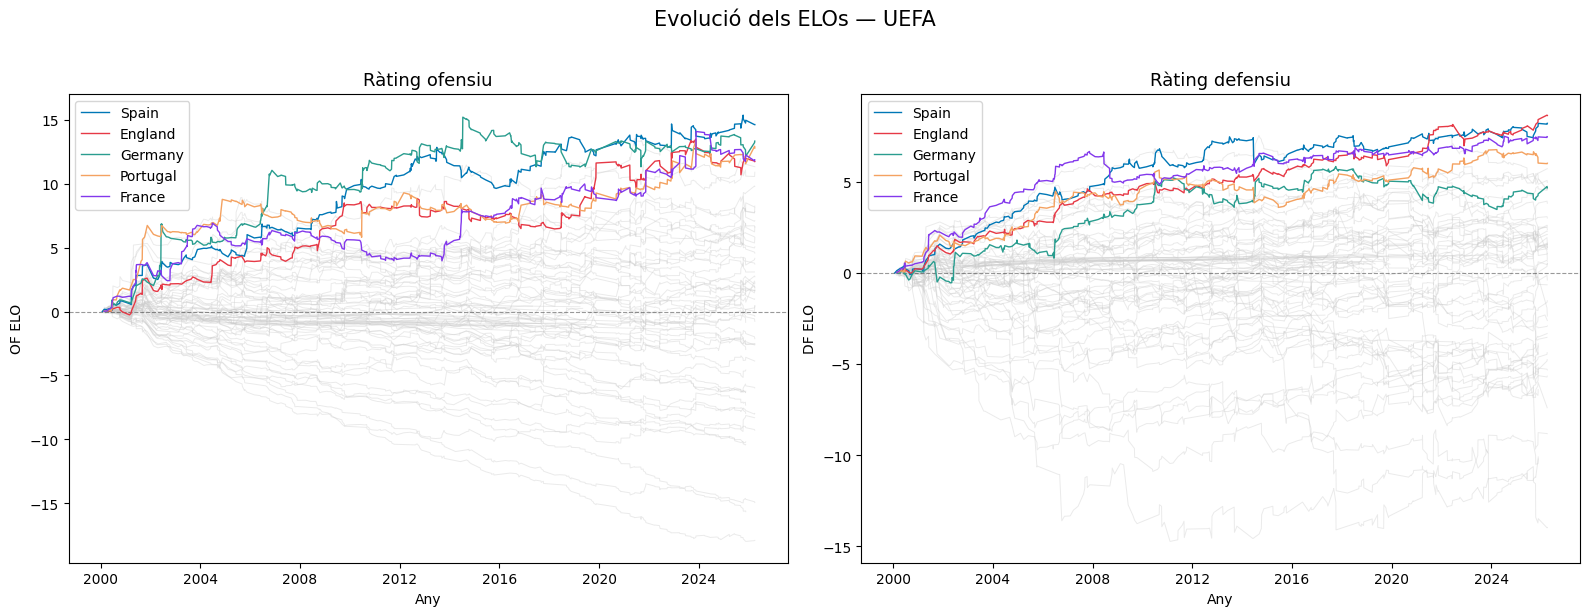

In [11]:
conf = 'UEFA'
highlight_teams = ['Spain', 'England', 'Germany', 'Portugal', 'France']
plot_elos_evolution(evolution, 'UEFA', conf_team_dict, highlight_teams)


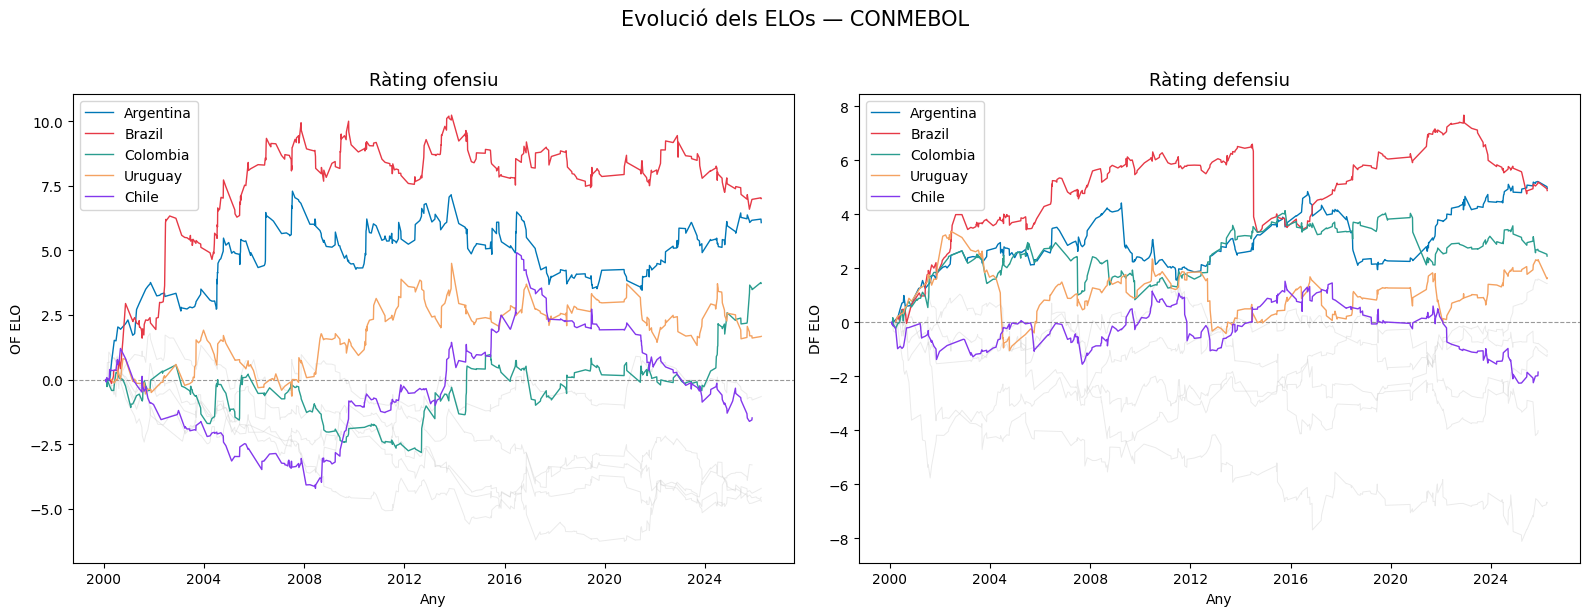

In [12]:
conf = 'CONMEBOL'
highlight_teams = ['Argentina', 'Brazil', 'Colombia', 'Uruguay', 'Chile']
plot_elos_evolution(evolution, conf, conf_team_dict, highlight_teams)

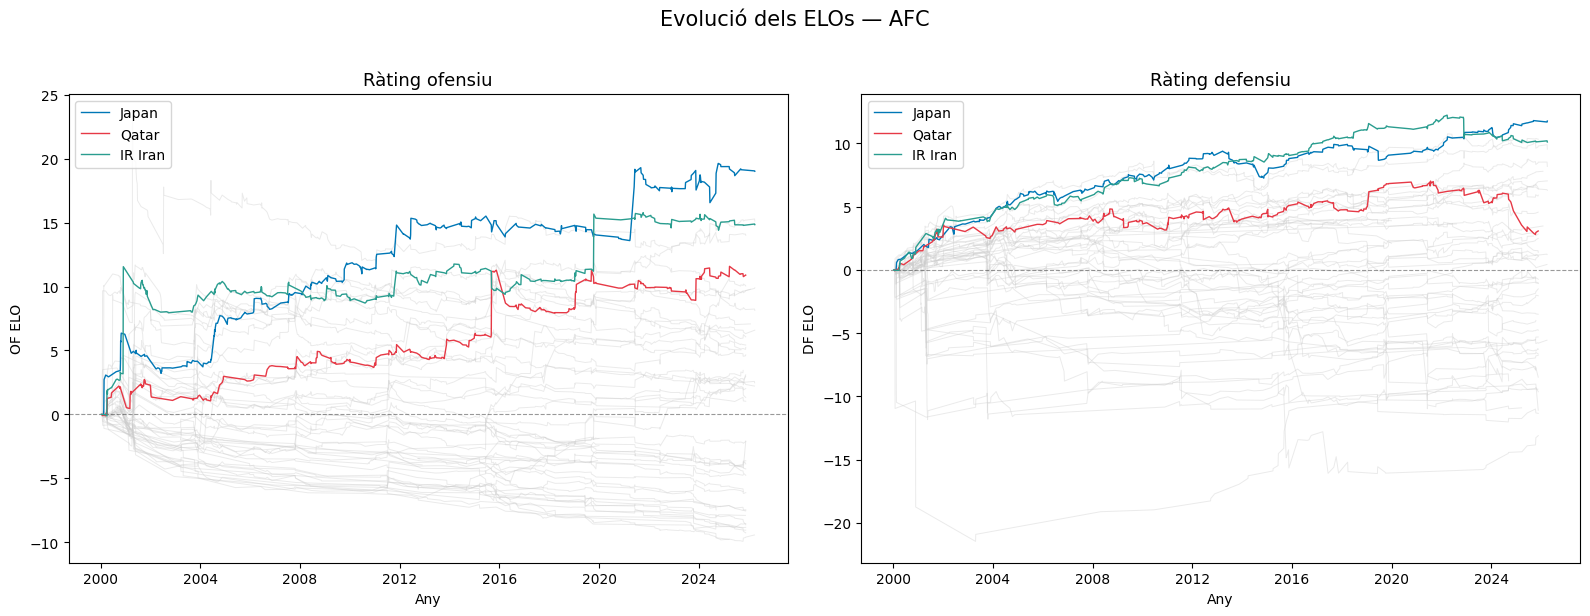

In [13]:
conf = 'AFC'
highlight_teams = ['Japan', 'Qatar', 'IR Iran']
plot_elos_evolution(evolution, conf, conf_team_dict, highlight_teams)

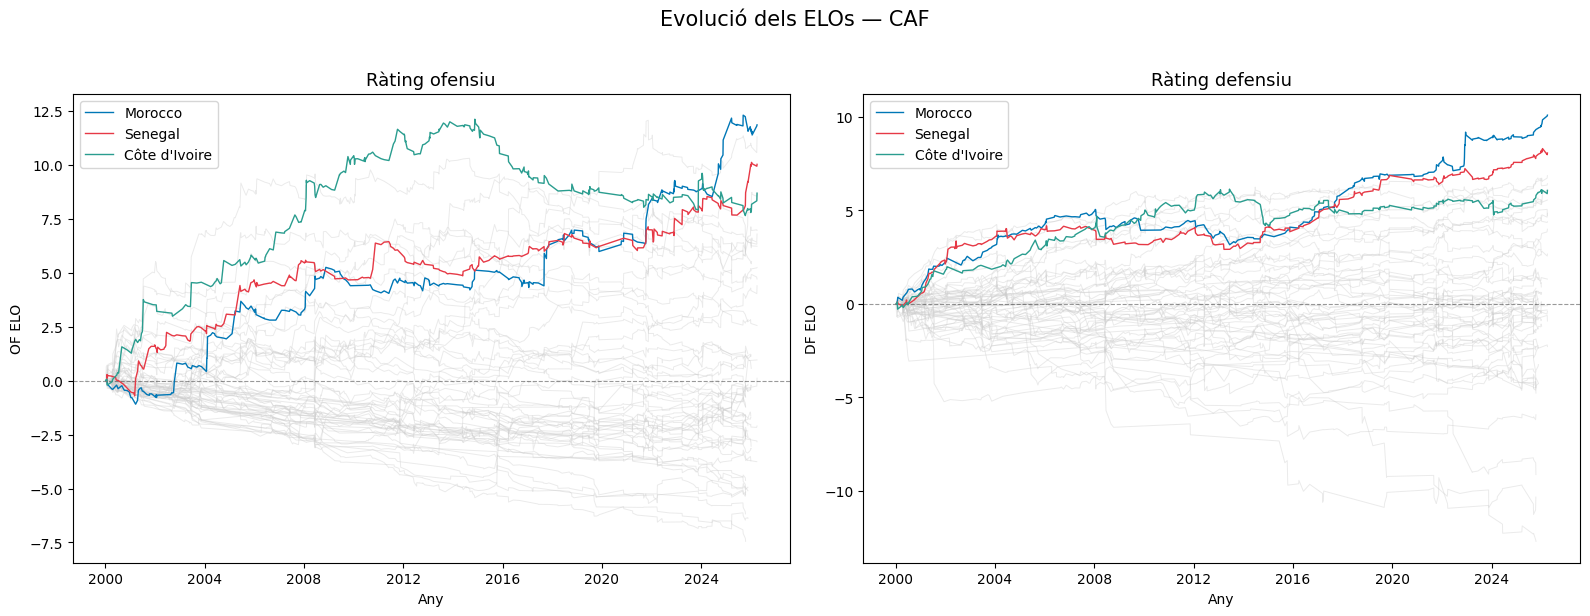

In [14]:
conf = 'CAF'
highlight_teams = ['Morocco', 'Senegal', "Côte d'Ivoire"]
plot_elos_evolution(evolution, conf, conf_team_dict, highlight_teams)

In [15]:
# Guardem els paràmetres finals i el ranking:
df_params = pd.json_normalize(params)
df_params.to_csv("../results/training/model_params.csv", index=False)

# 2. Guardar las variables de estado vivas (en data/processed/ porque se actualizarán)
# Guardamos los ELOs bivariantes de los equipos
df_ranking_csv = df_ranking[['Team', 'Off_ELO', 'Def_ELO']]
df_ranking_csv.to_csv('../data/processed/team_elos.csv', index=False) 

# Guardamos los Meta-ELOs de las confederaciones en la misma carpeta
df_confs.to_csv("../data/processed/conf_elos.csv", index=False)

Per observar com funciona el model i les probabilitats que assigna, per un España vs Portugal neutral:

In [16]:
def predict_match(home_team, away_team, df_ranking, df_confs, params, neutral=True):
    # Dades dels equips
    h_data = df_ranking[df_ranking["Team"] == home_team].iloc[0]
    a_data = df_ranking[df_ranking["Team"] == away_team].iloc[0]
    
    conf_map = dict(zip(df_confs["Confederation"], df_confs["Meta_ELO"]))
    gamma_h = conf_map[h_data["Conf"]]
    gamma_a = conf_map[a_data["Conf"]]
    
    # Calculem expected_goals amb els paràmetres estimats i dades dels equips
    h_adv = 0 if neutral else 1
    
    lambda_h = expected_goals(params, h_data["Off_ELO"], a_data["Def_ELO"], 
                              h_adv, gamma_h - gamma_a)
    
    lambda_a = expected_goals(params, a_data["Off_ELO"], h_data["Def_ELO"], 
                              -h_adv, gamma_a - gamma_h)
    
    # Matriu de probabilitats
    max_goals = 15

    prob_h = [poisson.pmf(i, lambda_h) for i in range(max_goals)]
    prob_a = [poisson.pmf(i, lambda_a) for i in range(max_goals)]
    
    matrix = np.outer(prob_h, prob_a)
    
    win_h = np.sum(np.tril(matrix, -1)) # i > j
    draw  = np.sum(np.diag(matrix))     # i == j
    win_a = np.sum(np.triu(matrix, 1))  # i < j
    
    return {
        "Home": home_team, "Away": away_team,
        "Exp_Goals_Home": lambda_h, "Exp_Goals_Away": lambda_a,
        "Prob_Win": win_h, "Prob_Draw": draw, "Prob_Loss": win_a
    }

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson


def visualize_match_marginals(home_team, away_team, lambda_1, lambda_2,
                                max_goals=10, save_path=None):
    """
    Visualitza les distribucions marginals de gols de dues seleccions
    segons el model Poisson bivariant.
    
    Parameters
    ----------
    home_team, away_team : str
        Noms de les seleccions.
    lambda_1, lambda_2 : float
        Gols esperats segons el model.
    max_goals : int
        Eix x màxim (per defecte 10).
    save_path : str, optional
        Ruta on guardar la figura.
    """
    goals = np.arange(max_goals + 1)
    p_home = poisson.pmf(goals, lambda_1) * 100
    p_away = poisson.pmf(goals, lambda_2) * 100
    
    # Probabilitats 1X2
    p_matrix = np.outer(poisson.pmf(goals, lambda_1),
                         poisson.pmf(goals, lambda_2))
    p_home_win = np.sum(np.tril(p_matrix, k=-1)) * 100
    p_draw     = np.sum(np.diag(p_matrix))         * 100
    p_away_win = np.sum(np.triu(p_matrix, k=1))    * 100
    
    fig, ax = plt.subplots(figsize=(11, 6))
    
    color_home = '#2e7d32'   # verd
    color_away = '#c62828'   # vermell
    
    # Distribucions amb àrea ombrada
    ax.fill_between(goals, p_home, alpha=0.2, color=color_home)
    ax.plot(goals, p_home, marker='o', markersize=7, color=color_home,
            linewidth=2, label=f'{home_team}  ($\\lambda_1 = {lambda_1:.2f}$)')
    
    ax.fill_between(goals, p_away, alpha=0.2, color=color_away)
    ax.plot(goals, p_away, marker='o', markersize=7, color=color_away,
            linewidth=2, label=f'{away_team}  ($\\lambda_2 = {lambda_2:.2f}$)')
    
    # Anotacions de % sobre els pics principals
    for g in goals[:6]:
        if p_home[g] > 1:
            ax.annotate(f'{p_home[g]:.1f}%', xy=(g, p_home[g]),
                        xytext=(0, 8), textcoords='offset points',
                        ha='center', fontsize=8.5, color=color_home,
                        fontweight='bold')
        if p_away[g] > 1:
            ax.annotate(f'{p_away[g]:.1f}%', xy=(g, p_away[g]),
                        xytext=(0, -16), textcoords='offset points',
                        ha='center', fontsize=8.5, color=color_away,
                        fontweight='bold')
    
    # Eixos
    ax.set_xlabel('Gols')
    ax.set_ylabel('Probabilitat (%)')
    ax.set_xticks(goals)
    ax.set_xlim(-0.5, max_goals + 0.5)
    ax.set_ylim(0, max(p_home.max(), p_away.max()) * 1.2)
    
    # Estètica
    ax.grid(axis='y', alpha=0.3)
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    # Títol amb probabilitats 1X2
    title = (f'Distribució de gols — {home_team} vs {away_team}\n'
             f'$P$({home_team}) = {p_home_win:.1f}%   |   '
             f'$P$(empat) = {p_draw:.1f}%   |   '
             f'$P$({away_team}) = {p_away_win:.1f}%')
    ax.set_title(title)
    
    ax.legend(loc='upper right', fontsize=11, frameon=True)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    
    return p_home_win, p_draw, p_away_win


Predicción: Mexico vs South Africa
Goles esperados: 1.18 - 0.77
Probabilidades: Gana Mexico 45.5%, Empate 30.5%, Gana South Africa 24.0%
Cuotas: Gana Mexico 2.2, Empate 3.3, Gana South Africa 4.2


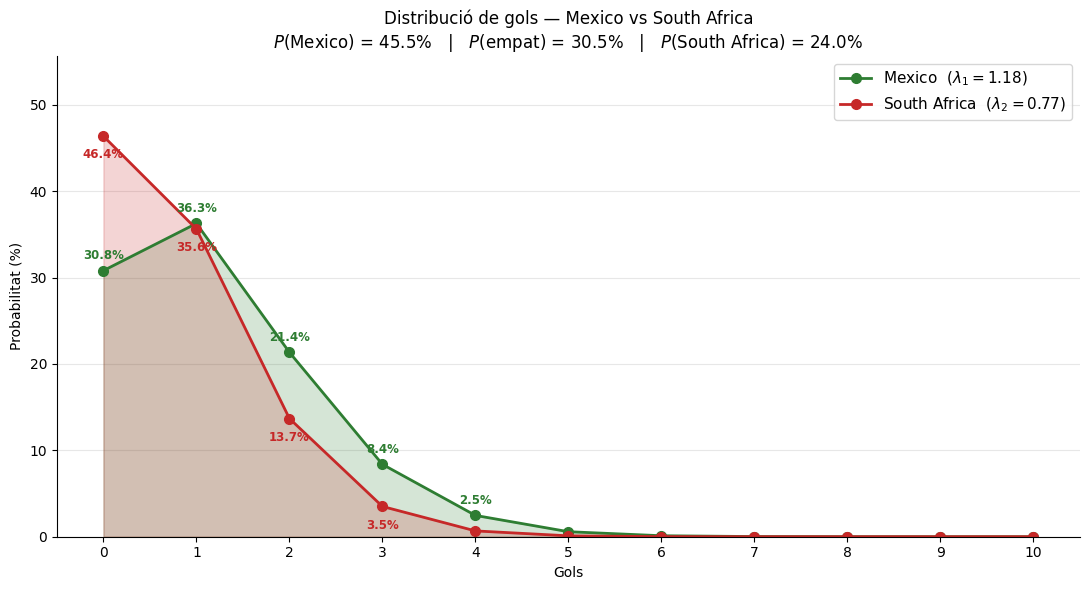

(np.float64(45.517437034417455),
 np.float64(30.451272925848244),
 np.float64(24.031284825710554))

In [18]:
h_team, a_team = "Mexico", "South Africa"
res = predict_match(h_team, a_team, df_ranking, df_confs, params, neutral=False)

print(f"Predicción: {res['Home']} vs {res['Away']}")
print(f"Goles esperados: {res['Exp_Goals_Home']:.2f} - {res['Exp_Goals_Away']:.2f}")
print(f"Probabilidades: Gana {res['Home']} {res['Prob_Win']:.1%}, Empate {res['Prob_Draw']:.1%}, Gana {res['Away']} {res['Prob_Loss']:.1%}")
print(f"Cuotas: Gana {res['Home']} {1/res['Prob_Win']:.1f}, Empate {1/res['Prob_Draw']:.1f}, Gana {res['Away']} {1/res['Prob_Loss']:.1f}")

visualize_match_marginals(
    home_team=h_team,
    away_team=a_team,
    lambda_1=res['Exp_Goals_Home'],
    lambda_2=res['Exp_Goals_Away'],
    # save_path='../latex/figures/match_distribution.png'
)

In [19]:
def make_result(home_team, away_team, current_elo_teams, current_elo_confs, params, neutral):
    # 1. Acceso instantáneo a los datos (sin .loc ni .iloc)
    h_data = current_elo_teams[home_team]
    a_data = current_elo_teams[away_team]

    # 2. Diferencia de Meta-ELO (usando el diccionario de confederaciones)
    conf_diff = current_elo_confs[h_data["Conf"]] - current_elo_confs[a_data["Conf"]]

    # 3. Ventaja de campo
    if neutral: # neutral ya es un booleano o 1/0
        h_adv, a_adv = 0, 0
    else:
        h_adv, a_adv = 1, -1

    # 4. Goles esperados (Lambda de Poisson)
    lam_home = expected_goals(params, h_data["Off_ELO"], a_data["Def_ELO"], h_adv, conf_diff)
    lam_away = expected_goals(params, a_data["Off_ELO"], h_data["Def_ELO"], a_adv, -conf_diff)

    # 5. Generar goles aleatorios
    goals_home = np.random.poisson(lam_home)
    goals_away = np.random.poisson(lam_away)

    return goals_home, goals_away, lam_home, lam_away

In [26]:
df_ranking

,Team,Off_ELO,Def_ELO,Conf
0,Egypt,6.764936,7.012541,CAF
1,Tunisia,6.894739,6.495732,CAF
2,Trinidad and Tobago,5.767292,2.206997,CONCACAF
3,Burkina Faso,4.361069,2.657702,CAF
4,Guatemala,8.280391,4.430016,CONCACAF
...,...,...,...,...
274,United Koreans in Japan,-2.740220,4.071744,AFC
275,Tamil Eelam,-3.261855,4.172608,AFC
276,Surrey,-1.295225,1.090166,UEFA
277,Saint Helena,-0.858479,0.498491,CAF


In [34]:
def simulate_match(n, h_team, a_team, df_ranking, df_confs, params, neutral):
    off_elo_home, def_elo_home = df_ranking[df_ranking["Team"] == h_team]["Off_ELO"].iloc[0], df_ranking[df_ranking["Team"] == h_team]["Def_ELO"].iloc[0]
    off_elo_away, def_elo_away = df_ranking[df_ranking["Team"] == a_team]["Off_ELO"].iloc[0], df_ranking[df_ranking["Team"] == a_team]["Def_ELO"].iloc[0]

    elo_conf_home, elo_conf_away = df_confs[df_confs["Confederation"] == team_conf_dict[h_team]]["Meta_ELO"].iloc[0], df_confs[df_confs["Confederation"] == team_conf_dict[a_team]]["Meta_ELO"].iloc[0]
    conf_diff = elo_conf_home - elo_conf_away

    if neutral:
        h_adv, a_adv = 0, 0
    else:
        h_adv, a_adv = 1, -1

    lam_home = expected_goals(params, off_elo_home, def_elo_away, h_adv, conf_diff)
    lam_away = expected_goals(params, off_elo_away, def_elo_home, a_adv, -conf_diff)

    h_goals, a_goals = np.array([]), np.array([])
    for i in range(n):
        goals_home = np.random.poisson(lam_home)
        goals_away = np.random.poisson(lam_away)

        h_goals = np.append(h_goals, goals_home)
        a_goals = np.append(a_goals, goals_away)
    
    return h_goals, a_goals

In [35]:
h_goals, a_goals = simulate_match(100000, h_team, a_team, df_ranking, df_confs, params, neutral = False)

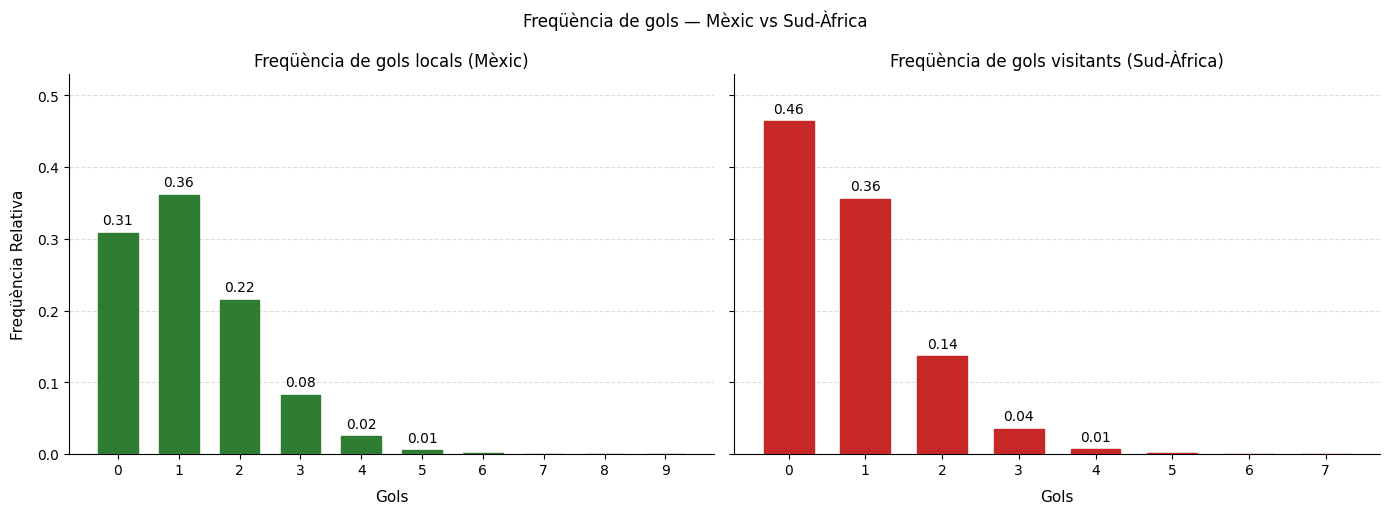

In [51]:
# 1. Procesar datos de Mèxic (Locals)
goles_h = h_goals.astype(int)
goles_mext, freq_mex = np.unique(goles_h, return_counts=True)
freq_mex = freq_mex / len(h_goals)

# 2. Procesar datos de Sud-Àfrica (Visitants)
goles_a = a_goals.astype(int)
goles_saf, freq_saf = np.unique(goles_a, return_counts=True)
freq_saf = freq_saf / len(a_goals) # Corregido para usar su propia longitud

# 3. Configurar lienzo con 2 subplots en una fila compartiendo el eje Y
fig, axes = plt.subplots(1, 2, figsize=(14, 5.2), sharey=True)
max_freq = max(max(freq_mex), max(freq_saf)) # Para ajustar el límite Y de forma global

# ==========================================
# PANEL ESQUERRE: MÈXIC (Gols Locals)
# ==========================================
axes[0].grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
barras_mex = axes[0].bar(goles_mext, freq_mex, color="#2e7d32", width=0.65, edgecolor="#2e7d32", zorder=3)

# Etiquetas de texto
for barra in barras_mex:
    alto = barra.get_height()
    if alto > 0.005:
        axes[0].text(
            barra.get_x() + barra.get_width() / 2.0,  
            alto + (max_freq * 0.015),        
            f'{alto:.2f}',                          
            ha='center', va='bottom'
        )

axes[0].set_title("Freqüència de gols locals (Mèxic)")
axes[0].set_xlabel("Gols", fontsize=11, labelpad=8)
axes[0].set_ylabel("Freqüència Relativa", fontsize=11, labelpad=8)
axes[0].set_xticks(goles_mext)

# ==========================================
# PANEL DRET: SUD-ÀFRICA (Gols Visitants)
# ==========================================
axes[1].grid(axis='y', linestyle='--', alpha=0.4, zorder=0)
barras_saf = axes[1].bar(goles_saf, freq_saf, color="#c62828", width=0.65, edgecolor="#c62828", zorder=3)

# Etiquetas de texto
for barra in barras_saf:
    alto = barra.get_height()
    if alto > 0.005:
        axes[1].text(
            barra.get_x() + barra.get_width() / 2.0,  
            alto + (max_freq * 0.015),        
            f'{alto:.2f}',                          
            ha='center', va='bottom'
        )

axes[1].set_title("Freqüència de gols visitants (Sud-Àfrica)")
axes[1].set_xlabel("Gols", fontsize=11, labelpad=8)
axes[1].set_xticks(goles_saf)

# ==========================================
# OPTIMIZACIÓN ESTÉTICA GLOBAL
# ==========================================
# Fijar límite Y equitativo para ambos paneles dejando espacio para las etiquetas de texto
plt.ylim(0, max_freq * 1.14)

# Eliminar bordes superior y derecho en ambos gráficos
for ax in axes:
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

# Título general de la figura unificada
fig.suptitle("Freqüència de gols — Mèxic vs Sud-Àfrica")

plt.tight_layout()
plt.show()